<a href="https://colab.research.google.com/github/IrineuBovoJunior398/Pos-em-IA/blob/main/DETEC%C3%87%C3%83O_RISCO_DIABETES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 50

# Variáveis simuladas
idade = np.random.randint(18, 80, n)
imc = np.round(np.random.normal(28, 5, n), 2)
glicose = np.random.randint(70, 200, n)
pressao = np.random.randint(90, 160, n)
historico_familiar = np.random.randint(0, 1+1, n)
atividade = np.round(np.random.uniform(0, 7, n), 1)

# Rótulo — risco de diabetes (regra simples)
risco = ((glicose > 130) | (imc > 30) | (historico_familiar == 1)).astype(int)

# Criando o dataset
df = pd.DataFrame({
    "idade": idade,
    "imc": imc,
    "glicose": glicose,
    "pressao": pressao,
    "historico_familiar": historico_familiar,
    "atividade_fisica": atividade,
    "risco_diabetes": risco
})

print(df)

    idade    imc  glicose  pressao  historico_familiar  atividade_fisica  \
0      56  28.71      131      147                   0               1.1   
1      69  27.83      106      141                   0               3.8   
2      46  33.67      168      101                   1               4.8   
3      32  27.48      173      128                   1               4.6   
4      60  25.37      104       91                   1               1.6   
5      25  37.56      170       92                   1               5.0   
6      78  17.87       70      145                   0               1.7   
7      38  33.60       74      148                   1               2.3   
8      56  31.90      172       91                   1               5.2   
9      75  22.49       96       91                   0               4.5   
10     36  33.65       84      143                   1               5.9   
11     40  29.87      159       90                   0               4.6   
12     28  2

   idade    imc  glicose  pressao  historico_familiar  atividade_fisica  \
0   56.0  28.71    131.0    147.0                 0.0               1.1   
1   69.0  27.83    106.0    141.0                 0.0               3.8   
2   46.0  33.67    168.0    101.0                 1.0               4.8   
3   32.0  27.48    173.0    128.0                 1.0               4.6   
4   60.0  25.37    104.0     91.0                 1.0               1.6   

   risco_diabetes  
0               1  
1               0  
2               1  
3               1  
4               1  
Total de linhas: 550


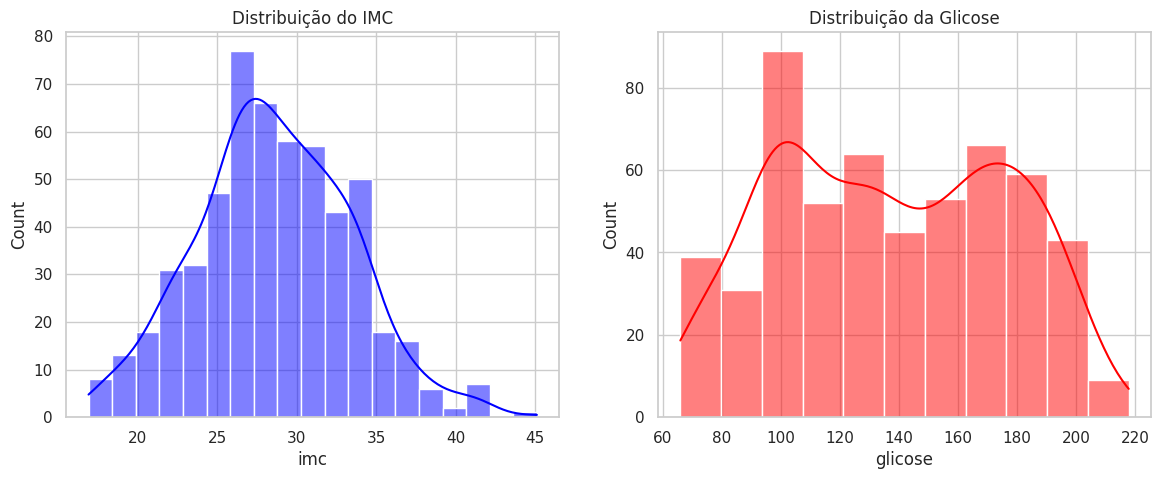

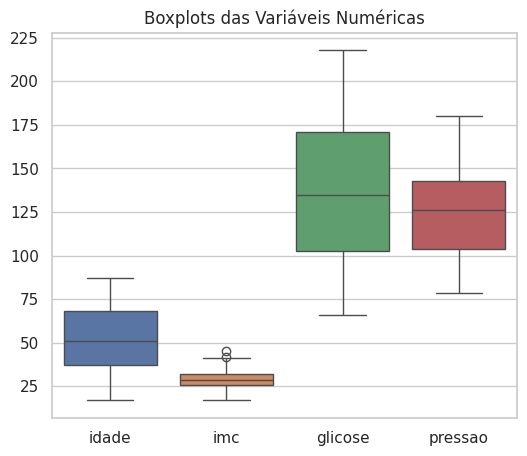

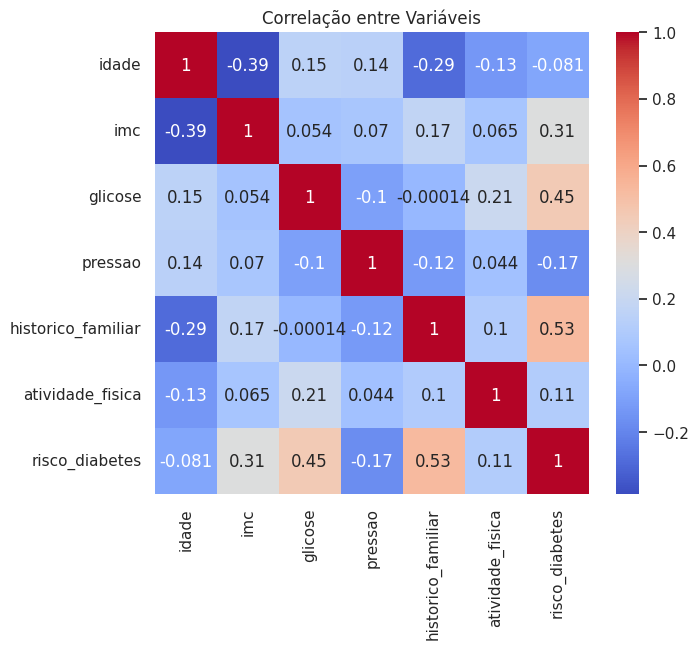

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Acurácia no teste: 1.0000


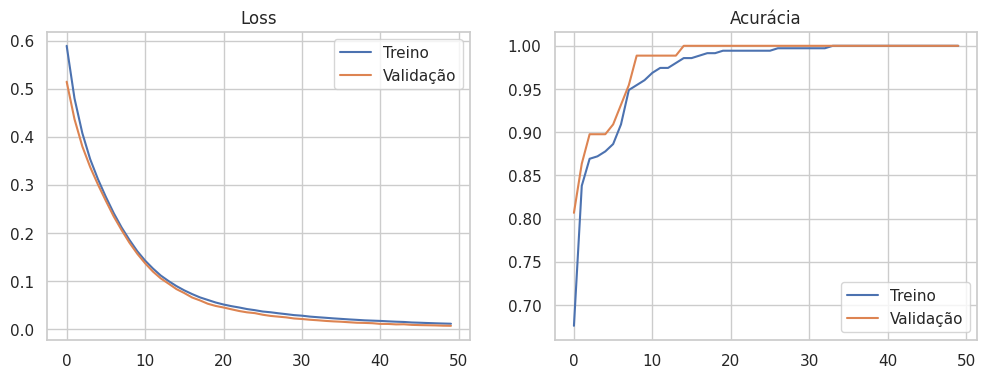

In [ ]:
# 1. Gerar e melhorar o dataset sintético (50 → 500 linhas)

import numpy as np
import pandas as pd
np.random.seed(42)

def gerar_dataset(n=50):
    idade = np.random.randint(18, 80, n)
    imc = np.round(np.random.normal(28, 5, n), 2)
    glicose = np.random.randint(70, 200, n)
    pressao = np.random.randint(90, 160, n)
    historico_familiar = np.random.randint(0, 2, n)
    atividade = np.round(np.random.uniform(0, 7, n), 1)

    risco = ((glicose > 130) | (imc > 30) | (historico_familiar == 1)).astype(int)

    df = pd.DataFrame({
        "idade": idade,
        "imc": imc,
        "glicose": glicose,
        "pressao": pressao,
        "historico_familiar": historico_familiar,
        "atividade_fisica": atividade,
        "risco_diabetes": risco
    })
    return df

df = gerar_dataset(50)

# --- AUMENTO SINTÉTICO (500 LINHAS) ---
def aumentar_dados(df, fator=10):
    df_aug = df.copy()
    for _ in range(fator):
        noise = np.random.normal(0, 0.05, df.drop(columns="risco_diabetes").shape)
        bloco = df.drop(columns="risco_diabetes") * (1 + noise)
        bloco = bloco.clip(lower=0)
        bloco["risco_diabetes"] = df["risco_diabetes"].values
        df_aug = pd.concat([df_aug, bloco], ignore_index=True)
    return df_aug

df_big = aumentar_dados(df)
print(df_big.head())
print("Total de linhas:", len(df_big))

# 2. Gráficos de análise do dataset

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
sns.histplot(df_big["imc"], kde=True, color="blue")
plt.title("Distribuição do IMC")

plt.subplot(1,2,2)
sns.histplot(df_big["glicose"], kde=True, color="red")
plt.title("Distribuição da Glicose")
plt.show()

plt.figure(figsize=(6,5))
sns.boxplot(data=df_big[["idade","imc","glicose","pressao"]])
plt.title("Boxplots das Variáveis Numéricas")
plt.show()

plt.figure(figsize=(7,6))
sns.heatmap(df_big.corr(), annot=True, cmap="coolwarm")
plt.title("Correlação entre Variáveis")
plt.show()

# 3. Divisão treino/teste + Normalização
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_big.drop("risco_diabetes", axis=1)
y = df_big["risco_diabetes"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Rede Neural (Keras)
# Pequena MLP para classificação binária.

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Dense(16, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(8, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=0
)
# 5. Avaliação da Rede Neural

loss, acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Acurácia no teste: {acc:.4f}")

# 6. Gráfico de treinamento (loss/accuracy)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="Treino")
plt.plot(history.history["val_loss"], label="Validação")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="Treino")
plt.plot(history.history["val_accuracy"], label="Validação")
plt.title("Acurácia")
plt.legend()

plt.show()
# 7. Tudo pronto
# Com este código você tem:

# Dataset base de 50 linhas
# Dataset ampliado para 500 linhas
# Visualização dos dados
# Normalização + treino/teste
# Rede neural completa
# Gráficos de treinamento

# Ajustar parâmetros
#Criar uma rede mais profunda
#Exportar o modelo
#Criar pipeline Scikit-Learn
#Gerar CSV final
#Quer avançar para qual dessas opções?












